“Modelo de Valor Relativo y Backtesting Multiactivo”


Modelo de valor relativo (Equity Risk Premium) con validación de cotizaciones,
simulación de operaciones y generación de reportes normativos.

In [2]:
#Importar Librerias necesarias
import os
import pandas as pd
import numpy as np
import yfinance as yf
from datetime import datetime, timedelta



In [3]:
# Configuración
DATA_DIR = "data"
LOGS_DIR = "logs"
TRADES_DIR = "trades"
REPORTS_DIR = "reports"

MIN_EQUITY = 0.40 # Min permitido de renta variable
MAX_EQUITY = 0.60 
NEUTRAL_EQUITY = 0.50 #El portafolio se divide en 50/50 renta variable y fija
Z_OVERWEIGHT = 1.5 #si Z-score > 1.5 → sobreponderar acciones 
Z_UNDERWEIGHT = -1.5
ROLLING_WINDOW = 360 #n para calcular media y desv #200,252,360 Depende reaccion al cambio

# Carpetas
for d in [DATA_DIR, LOGS_DIR, TRADES_DIR, REPORTS_DIR]:
    os.makedirs(d, exist_ok=True)
    print(f"Carpeta lista: {d}")

Carpeta lista: data
Carpeta lista: logs
Carpeta lista: trades
Carpeta lista: reports


Descargar y preprocesar datos

In [4]:
def download_data():
    print("Descargando datos...")
    end_date = datetime.now()
    start_date = end_date - timedelta(days=2*365)
    
    # Descargar índice S&P 500 #SPY da error se uso: ^GSPC
    gspc = yf.download("^GSPC", start=start_date, end=end_date, progress=False)
    if gspc.empty:
        raise Exception("No se descargó ^GSPC")
    gspc = gspc[['Close']].rename(columns={'Close': 'SPY_Close'})
    # ERROR/SOLUCION si es MultiIndex
    if isinstance(gspc.columns, pd.MultiIndex):
        gspc.columns = gspc.columns.droplevel(1)
    
    # Obtener PE (Ratio Precio-Beneficio) actual 
    spy_info = yf.Ticker("SPY")
    pe = spy_info.info.get('trailingPE', 26.8) #Si falla usar el valor obtenido manualmente de Yahoo Aprox
    print(f"PE actual del S&P 500: {pe}")
    gspc['PE'] = pe  #Se usa un PE constante 
    gspc['Earnings_Yield'] = 1.0 / pe #para calcular ERP, se asume constante
    
    # Descargar rendimiento del bono a 10 años Tesoro USA
    tnx = yf.download("^TNX", start=start_date, end=end_date, progress=False)
    if tnx.empty:
        raise Exception("No se descargó ^TNX")
    tnx = tnx[['Close']].rename(columns={'Close': 'TNX_Yield'})
    if isinstance(tnx.columns, pd.MultiIndex):
        tnx.columns = tnx.columns.droplevel(1)
    tnx['TNX_Yield'] = tnx['TNX_Yield'] / 100.0  # convertir a decimal
    
    # Combinar
    data = pd.merge(gspc, tnx, left_index=True, right_index=True, how='inner')
    data.dropna(inplace=True)
    return data

In [5]:
data = download_data()
print(f"Datos desde {data.index.min().date()} hasta {data.index.max().date()}")
print(f"Registros: {len(data)}")
data.tail()

Descargando datos...
PE actual del S&P 500: 26.956612
Datos desde 2024-04-09 hasta 2026-04-09
Registros: 502


Price,SPY_Close,PE,Earnings_Yield,TNX_Yield
Date,,,,
2026-04-02,6582.689941,26.956612,0.037097,0.04313
2026-04-06,6611.830078,26.956612,0.037097,0.04335
2026-04-07,6616.850098,26.956612,0.037097,0.04343
2026-04-08,6782.810059,26.956612,0.037097,0.04291
2026-04-09,6824.660156,26.956612,0.037097,0.04293


Detectar Outlier (valor que se aleja mucho de lo normal)

- Método: Mediana de Desviaciones Absolutas (MAD) con ventana de 5 días.
- Umbral: Si el último valor se desvía más de 3 MADs respecto a la mediana anterior, se genera alerta para revision profunda

In [6]:
def detect_outliers(series, window=5, mad_threshold=3.0): 
    # Si es DataFrame, tomar la primera columna como Serie
    if isinstance(series, pd.DataFrame):
        series = series.iloc[:, 0]
    # Asegurar que sea una Serie plana
    series = pd.Series(series).dropna()
    if len(series) < window + 1:
        return False, None, None, 0.0, None
    
    # Obtener último valor como escalar
    last_value = series.iloc[-1]
    # Si es array o Serie, extraer el primer elemento
    if hasattr(last_value, '__len__'):
        last_value = last_value.iloc[0] if hasattr(last_value, 'iloc') else last_value[0]
    last_value = float(last_value)
    
    # Ventana de valores previos
    prev_values = series.iloc[-window-1:-1]
    median = np.median(prev_values)
    mad = np.median(np.abs(prev_values - median)) #Mediana de Desviaciones Absolutas
    if mad == 0:
        return False, mad, median, 0.0, last_value
    
    deviation = abs(last_value - median) / mad
    is_outlier = deviation > mad_threshold
    return bool(is_outlier), float(mad), float(median), float(deviation), last_value

In [7]:
outliers = []
for col in ['SPY_Close', 'TNX_Yield']:
    is_out, mad, med, dev, last_val = detect_outliers(data[col]) #T/F
    if is_out:
        msg = f"{col} - último valor {last_val:.4f} se desvía {dev:.1f} MAD (umbral 3.0)"
        print("ALERTA:", msg)
        outliers.append(msg)
    else:
        print(f"{col}: sin outliers (desviación MAD: {dev:.1f})")

ALERTA: SPY_Close - último valor 6824.6602 se desvía 7.3 MAD (umbral 3.0)
TNX_Yield: sin outliers (desviación MAD: 1.6)


In [8]:
data.info() #Utilizado para buscar la causa de un error ya solucionado

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 502 entries, 2024-04-09 to 2026-04-09
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   SPY_Close       502 non-null    float64
 1   PE              502 non-null    float64
 2   Earnings_Yield  502 non-null    float64
 3   TNX_Yield       502 non-null    float64
dtypes: float64(4)
memory usage: 19.6 KB


Modelaje

-  El Equity Risk Premium (ERP) se estima como la diferencia entre el Earnings Yield del mercado accionario y la tasa libre de riesgo (bonos del Tesoro a 10 años).
-  Este indicador permite evaluar si el mercado accionario ofrece una prima atractiva frente a activos libres de riesgo.

- Formula:
  ERP = Earnings Yield - TNX Yield  
  donde Earnings Yield = 1 / PE (PE actual del S&P 500 vía ETF SPY) y TNX Yield es el rendimiento del bono del Tesoro USA a 10 años (tasa libre de riesgo).
- Z-score:
  Z = (ERP_actual - media_ventana) / desviación_ventana 
  Ventana móvil de 360 días
- Reglas de asignación táctica:
  - `Z > 1.5` → Sobreponderar acciones (60% equity, 40% renta fija).
  - `Z < -1.5` → Infraponderar acciones (40% equity, 60% renta fija).
  - `-1.5 ≤ Z ≤ 1.5` → Neutral (50% equity, 50% renta fija).

In [9]:
# Calcular ERP 
data['ERP'] = data['Earnings_Yield'] - data['TNX_Yield']

# Calcular media y std móvil del ERP para Z
data['ERP_mean'] = data['ERP'].rolling(window=ROLLING_WINDOW).mean()
data['ERP_std'] = data['ERP'].rolling(window=ROLLING_WINDOW).std()

# Calcular Z-score
data['Z_score'] = (data['ERP'] - data['ERP_mean']) / data['ERP_std']

# Obtener valores del último día
last = data.iloc[-1]
erp = last['ERP']
z_score = last['Z_score'] if not np.isnan(last['Z_score']) else 0.0

print(f"ERP actual: {erp:.4f} ({erp*100:.2f}%)")
print(f"Z-score (ventana {ROLLING_WINDOW} días): {z_score:.2f}")
print(f"Earnings Yield: {last['Earnings_Yield']:.4f}")
print(f"TNX Yield: {last['TNX_Yield']:.4f}")

ERP actual: -0.0058 (-0.58%)
Z-score (ventana 360 días): -0.07
Earnings Yield: 0.0371
TNX Yield: 0.0429


In [10]:
def generate_signal(z_score):
    if z_score > Z_OVERWEIGHT:
        return "SOBREPONDER ACCIONES", MAX_EQUITY
    elif z_score < Z_UNDERWEIGHT:
        return "INFRAPONDER ACCIONES", MIN_EQUITY
    else:
        return "NEUTRAL", NEUTRAL_EQUITY

signal_text, target_equity = generate_signal(z_score)
print(f"Señal: {signal_text}")
print(f"Asignación recomendada: Equity {target_equity*100:.0f}% / Renta fija {(1-target_equity)*100:.0f}%")

Señal: NEUTRAL
Asignación recomendada: Equity 50% / Renta fija 50%


Guardar la ultima asignacion y se lee para conocer la asignacion actual proximos dias

In [11]:
allocation_file = os.path.join(DATA_DIR, "last_allocation.csv")

if os.path.exists(allocation_file):
    prev_df = pd.read_csv(allocation_file)
    prev_equity = prev_df.iloc[-1]['equity']
    print(f"Asignación previa: Equity {prev_equity*100:.0f}%")
else:
    prev_equity = NEUTRAL_EQUITY
    print(f"No había asignación previa. Usando neutral: Equity {prev_equity*100:.0f}%")

Asignación previa: Equity 50%


Simulacion de operaciones

In [12]:
delta = target_equity - prev_equity #Calcular la diferencia de asignación
portfolio_value = 1_000_000
current_price = last['SPY_Close']  # escalar

if abs(delta) > 0.001:
    amount = portfolio_value * delta
    quantity = abs(amount) / current_price
    side = "COMPRA" if amount > 0 else "VENTA"
    trades = [{
        'Fecha': datetime.now().strftime('%Y-%m-%d'),
        'Activo': 'SPY',
        'Operacion': side,
        'Cantidad': round(quantity, 4),
        'Precio': round(current_price, 4),
        'Motivo': f"Señal ERP (Z={z_score:.2f})"
    }]
    print("Operación simulada:")
    print(trades[0])
else:
    trades = []
    print("No hay cambios en asignación.")

No hay cambios en asignación.


In [13]:
allocation_df = pd.DataFrame([{
    'fecha': datetime.now().strftime('%Y-%m-%d'),
    'equity': target_equity,
    'fixed_income': 1 - target_equity
}])
allocation_df.to_csv(allocation_file, index=False)
print("Asignación actualizada.")

Asignación actualizada.


In [14]:
today = datetime.now().strftime('%Y%m%d')
if trades:
    trades_df = pd.DataFrame(trades)
    cierre_path = os.path.join(REPORTS_DIR, f"cierre_operaciones_{today}.csv")
    trades_df.to_csv(cierre_path, index=False)
    print(f"Reporte de operaciones guardado: {cierre_path}")
    
    # Actualizar historial de trades
    log_file = os.path.join(TRADES_DIR, "trade_log.csv")
    if os.path.exists(log_file):
        old = pd.read_csv(log_file)
        updated = pd.concat([old, trades_df], ignore_index=True)
    else:
        updated = trades_df
    updated.to_csv(log_file, index=False)
    print(f"Historial de trades actualizado: {log_file}")
else:
    print("No hay operaciones. No se genera CSV.")

No hay operaciones. No se genera CSV.


Reporte

- En carpeta reports

In [15]:
md_lines = []
md_lines.append(f"# Reporte de Valor Relativo - {datetime.now().strftime('%Y-%m-%d')}")
md_lines.append("")
md_lines.append("## Resumen del modelo ERP")
md_lines.append(f"- **ERP actual**: {erp:.4f} ({erp*100:.2f}%)")
md_lines.append(f"- **Z-score (ventana {ROLLING_WINDOW} días)**: {z_score:.2f}")
md_lines.append(f"- **Señal**: {signal_text}")
md_lines.append(f"- **Asignación recomendada**: Equity {target_equity*100:.0f}% / Renta Fija {(1-target_equity)*100:.0f}%")
md_lines.append("")
md_lines.append("## Validación de cotizaciones")
if outliers:
    for o in outliers:
        md_lines.append(f"- Alerta: {o}")
else:
    md_lines.append("- No se detectaron outliers significativos.")
md_lines.append("")
md_lines.append("## Cumplimiento de régimen")
md_lines.append(f"- Límite mínimo equity: {MIN_EQUITY*100:.0f}%")
md_lines.append(f"- Límite máximo equity: {MAX_EQUITY*100:.0f}%")
md_lines.append(f"- Asignación propuesta: {target_equity*100:.0f}% → **CUMPLE**")
md_lines.append("")
md_lines.append("## Operaciones realizadas hoy")
if trades:
    md_lines.append("| Activo | Operación | Cantidad | Precio | Motivo |")
    md_lines.append("|--------|-----------|----------|--------|--------|")
    for t in trades:
        md_lines.append(f"| {t['Activo']} | {t['Operacion']} | {t['Cantidad']} | {t['Precio']} | {t['Motivo']} |")
else:
    md_lines.append("No se realizaron operaciones.")
md_lines.append("")
md_lines.append("---")
md_lines.append("*Reporte generado automáticamente*")

md_content = "\n".join(md_lines)
report_file = os.path.join(REPORTS_DIR, f"reporte_valor_relativo_{today}.md")
with open(report_file, "w") as f:
    f.write(md_content)
print(f"Reporte Markdown guardado: {report_file}")

Reporte Markdown guardado: reports\reporte_valor_relativo_20260409.md


RATIO commodity/Equity  = Oro/SP

- Ratio: Gold_SPY_Ratio = Precio Oro / Precio S&P 500.
- Z-score del ratio con la misma ventana de dias
- Señal: 
  - `Z > 1.5` → Oro sobrevalorado vs acciones → Infraponderar commodities.  
  - `Z < -1.5` → Oro infravalorado vs acciones → Sobreponderar commodities.  
  - En caso contrario → Neutral.

In [16]:
# Descargar precio del oro
gold = yf.download("GC=F", start=data.index.min(), end=datetime.now(), progress=False)
if gold.empty:
    raise Exception("No se descargó GC=F")
gold = gold[['Close']].rename(columns={'Close': 'Gold_Close'})
if isinstance(gold.columns, pd.MultiIndex):
    gold.columns = gold.columns.droplevel(1)
print(f"Oro: {len(gold)} registros")
gold.tail()

Oro: 504 registros


Price,Gold_Close
Date,
2026-04-02,4651.500000
2026-04-06,4656.799805
2026-04-07,4657.100098
2026-04-08,4749.500000
2026-04-09,4790.500000


Compara el precio del oro contra el precio del S&P 500 para determinar si el oro está barato o caro relativamente.

In [17]:
# Unir con los datos existentes (SPY)
commodity_data = data[['SPY_Close']].copy()
commodity_data = commodity_data.merge(gold, left_index=True, right_index=True, how='inner')
commodity_data.dropna(inplace=True)

# Calcular ratio: Precio Oro / Precio S&P 500
commodity_data['Gold_SPY_Ratio'] = commodity_data['Gold_Close'] / commodity_data['SPY_Close']

# Z-score del ratio 
commodity_data['Ratio_mean'] = commodity_data['Gold_SPY_Ratio'].rolling(window=ROLLING_WINDOW).mean()
commodity_data['Ratio_std'] = commodity_data['Gold_SPY_Ratio'].rolling(window=ROLLING_WINDOW).std()
commodity_data['Ratio_Z'] = (commodity_data['Gold_SPY_Ratio'] - commodity_data['Ratio_mean']) / commodity_data['Ratio_std']

# Últimos valores
last_ratio_z = commodity_data['Ratio_Z'].iloc[-1]
last_ratio = commodity_data['Gold_SPY_Ratio'].iloc[-1]

print(f"Ratio Oro/SPY actual: {last_ratio:.4f}")
print(f"Z-score del ratio (ventana {ROLLING_WINDOW}): {last_ratio_z:.2f}")

# Señal para commodities
if last_ratio_z > 1.5:
    commodity_signal = "SOBREPONDER COMMODITIES (Oro barato vs SPY)"
elif last_ratio_z < -1.5:
    commodity_signal = "INFRAPONDER COMMODITIES (Oro caro vs SPY)"
else:
    commodity_signal = "NEUTRAL en Commodities"

print(f"Señal Commodities: {commodity_signal}")

Ratio Oro/SPY actual: 0.7019
Z-score del ratio (ventana 360): 1.47
Señal Commodities: NEUTRAL en Commodities


In [ ]:
if z_score > 1.0 and last_ratio_z > 1.0:
    combined = "Sobreponderar Acciones y Commodities"
elif z_score < -1.0 and last_ratio_z < -1.0:
    combined = "Infraponderar Acciones y Commodities, favorecer Renta Fija"
else:
    combined = "Distribución neutral, monitorear señales"

print(f"Recomendación combinada: {combined}")

# Ampliar el reporte anterior
today = datetime.now().strftime('%Y%m%d')
md_extra = f"""

## Modelo de Commodities (Oro vs S&P 500)
- **Ratio Oro/SPY actual**: {last_ratio:.4f}
- **Z-score del ratio**: {last_ratio_z:.2f}
- **Señal**: {commodity_signal}

## Recomendación combinada (ERP + Commodities)
{combined}

---
*Reporte actualizado con modelo de commodities*
"""

# Leer reporte anterior si existe y agregar
report_file = os.path.join(REPORTS_DIR, f"reporte_valor_relativo_{today}.md")
with open(report_file, "a", encoding="utf-8") as f:
    f.write(md_extra)

print(f"Reporte actualizado con commodities en: {report_file}")

Recomendación combinada: Distribución neutral, monitorear señales
Reporte actualizado con commodities en: reports\reporte_valor_relativo_20260409.md


In [19]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

In [ ]:
# Crear un DataFrame con los 3 activos para correlación
# - S&P 500: rendimientos diarios (log returns)
# - Bonos (TNX): cambios diarios en yield
# - Oro: rendimientos diarios

# Calcular rendimientos diarios (%)
corr_data = pd.DataFrame()
corr_data['SP500_Return'] = data['SPY_Close'].pct_change() * 100
corr_data['Bond_Change'] = data['TNX_Yield'].diff() * 100  # cambio en puntos porcentuales
corr_data['Gold_Return'] = commodity_data['Gold_Close'].pct_change() * 100

# Eliminar valores NaN (primer día)
corr_data.dropna(inplace=True)

# Calcular matriz de correlación
correlation_matrix = corr_data.corr()

print(" MATRIZ DE CORRELACIÓN")
print("(Rendimientos diarios en % para SP500 y Oro; cambios en yield para Bonos)")
print(correlation_matrix.round(4))

=== MATRIZ DE CORRELACIÓN ===
(Rendimientos diarios en % para SP500 y Oro; cambios en yield para Bonos)
              SP500_Return  Bond_Change  Gold_Return
SP500_Return        1.0000       0.0576       0.0892
Bond_Change         0.0576       1.0000      -0.1131
Gold_Return         0.0892      -0.1131       1.0000


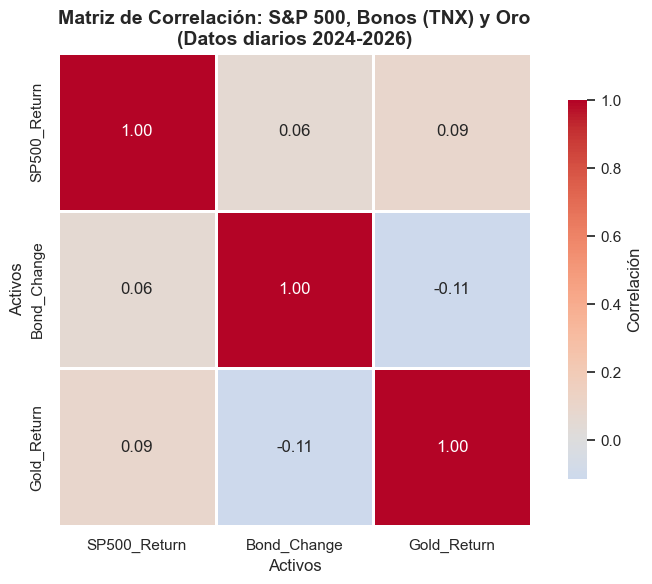

Mapa de calor guardado en: reports\matriz_correlacion.png


In [ ]:
plt.figure(figsize=(8, 6))
sns.set_theme(style="whitegrid")

heatmap = sns.heatmap(
    correlation_matrix,
    annot=True,           # Mostrar valores numéricos
    cmap='coolwarm',      # Colores: rojo (correlación positiva), azul (negativa)
    center=0,             # Centro en 0
    square=True,          # Celdas cuadradas
    fmt='.2f',            # Formato de 2 decimales
    linewidths=1,         # Líneas entre celdas
    cbar_kws={'shrink': 0.8, 'label': 'Correlación'}
)

# Títulos y etiquetas
plt.title('Matriz de Correlación: S&P 500, Bonos (TNX) y Oro\n(Datos diarios 2024-2026)', 
          fontsize=14, fontweight='bold')
plt.xlabel('Activos', fontsize=12)
plt.ylabel('Activos', fontsize=12)

plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, "matriz_correlacion.png"), dpi=150, bbox_inches='tight')
plt.show()

print(f"Mapa de calor guardado en: {os.path.join(REPORTS_DIR, 'matriz_correlacion.png')}")